In [1]:
from dotenv import load_dotenv
load_dotenv()

False

In [3]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

In [4]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("openai:gpt-5-mini")

In [5]:
from langchain_core.tools import tool

@tool
def get_stock_price(symbol: str) -> float:
    '''
    Return the stock price of a stock given the stock symbol
    :param symbol: stock symbol
    :return: current price of the stock
    '''
    return {
        "MSFT": 200.3,
        "AAPL": 100.4,
        "AMZN": 150.0,
        "RIL": 87.6
    }.get(symbol, 0.0)

tools = [get_stock_price]

In [6]:
llm_with_tools = llm.bind_tools(tools)

In [7]:
def chatbot(state:State) -> State:
    return {"messages": [llm_with_tools.invoke(state['messages'])]}

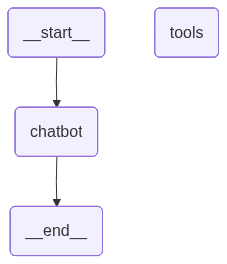

In [8]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

builder = StateGraph(State)
builder.add_node("chatbot", chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

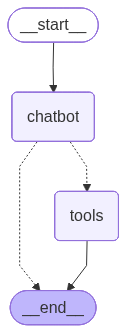

In [9]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(State)
builder.add_node("chatbot", chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
state = graph.invoke({"messages": [{"role": "user", "content": "What is the price of AMZN stock right now?"}]})
state["messages"][-1].content

'150.0'

In [24]:
state = graph.invoke({"messages": [{"role": "user", "content": "What is the price of MSFT stock right now?"}]})
state["messages"][-1].content

'200.3'

In [25]:
state = graph.invoke({"messages": [{"role": "user", "content": "Who inveneted the theory of relativity? Print the person name only"}]})
state["messages"][-1].content

'Albert Einstein'

In [10]:
msg = "I want to buy 20 AMZN stocks using the current price. Then 15 MSFT. What will be the total cost?"

state = graph.invoke({"messages": [{"role": "user", "content": msg}]})
state["messages"][-1].content

'200.3'